In [6]:
# Re-run safe pipeline

In [13]:
!pip install yfinance

In [17]:
import pandas as pd
import yfinance as yf

companies = ["MSFT", "CRM", "SHOP", "ADBE"]

all_data = []

for company in companies:
    ticker = yf.Ticker(company)
    df = ticker.quarterly_financials.T

    df.columns = df.columns.str.strip()

    temp = pd.DataFrame(index=df.index)

    temp["Company"] = company
    temp["Revenue"] = df.get("Total Revenue")
    temp["NetIncome"] = df.get("Net Income")
    temp["OperatingIncome"] = df.get("Operating Income")

    temp = temp.sort_index()

    all_data.append(temp)

final_df = pd.concat(all_data)

final_df.reset_index(inplace=True)
final_df.rename(columns={"index": "Date"}, inplace=True)

final_df["Revenue_Growth"] = (
    final_df.groupby("Company")["Revenue"].pct_change()
)

/tmp/ipykernel_1498/299518609.py:31: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  final_df.groupby("Company")["Revenue"].pct_change()


In [19]:
company_info = pd.DataFrame({
    "Company": ["MSFT", "CRM", "SHOP", "ADBE"],
    "Country": ["USA", "USA", "Canada", "USA"],
    "Sector": ["Tech", "SaaS", "E-commerce", "Creative"]
})

In [20]:
merged_df = pd.merge(
    final_df,
    company_info,
    on="Company",
    how="left"
)

In [18]:
final_df.head()

,Date,Company,Revenue,NetIncome,OperatingIncome,Revenue_Growth
0,2025-03-31,MSFT,7.006600e+10,2.582400e+10,3.200000e+10,NaN
1,2025-06-30,MSFT,7.644100e+10,2.723300e+10,3.432300e+10,0.090986
2,2025-09-30,MSFT,7.767300e+10,2.774700e+10,3.796100e+10,0.016117
3,2025-12-31,MSFT,8.127300e+10,3.845800e+10,3.827500e+10,0.046348
4,2026-03-31,MSFT,8.288600e+10,3.177800e+10,3.839800e+10,0.019847


In [13]:
import os
print(os.listdir())

['.config', 'drive', 'saas_kpi_analysis.csv', 'sample_data']


In [6]:
df.describe()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,Revenue,SGA,NetIncome,Revenue_Growth,Revenue_Diff,Magic_Number
count,2.500000e+01,29.0,2.500000e+01,20.000000,2.000000e+01,20.0
mean,1.963225e+10,0.0,6.810099e+09,0.049552,7.922929e+08,NaN
std,2.987642e+10,0.0,1.215272e+10,0.077357,1.580198e+09,NaN
min,7.141370e+08,0.0,-6.820000e+08,-0.136710,-5.020000e+08,-inf
25%,2.680000e+09,0.0,5.442600e+07,0.019780,4.435375e+07,NaN
50%,6.194000e+09,0.0,1.712000e+09,0.040928,2.050000e+08,NaN
75%,1.113300e+10,0.0,2.086000e+09,0.064316,8.565000e+08,NaN
max,8.288600e+10,0.0,3.845800e+10,0.291139,6.375000e+09,inf


In [7]:
df.isnull().sum()

,0
Date,0
Revenue,4
SGA,0
NetIncome,4
Company,0
Revenue_Growth,9
Revenue_Diff,9
Magic_Number,9


In [9]:
final_df["Revenue_Growth"] = final_df.groupby("Company")["Revenue"].pct_change()

/tmp/ipykernel_1172/1083175368.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  final_df["Revenue_Growth"] = final_df.groupby("Company")["Revenue"].pct_change()


In [9]:
df.sort_values("NetIncome", ascending=False).head(10)

,Date,Revenue,SGA,NetIncome,Company,Revenue_Growth,Revenue_Diff,Magic_Number
3,2025-12-31,8.127300e+10,0,3.845800e+10,MSFT,0.046348,3.600000e+09,inf
4,2026-03-31,8.288600e+10,0,3.177800e+10,MSFT,0.019847,1.613000e+09,inf
2,2025-09-30,7.767300e+10,0,2.774700e+10,MSFT,0.016117,1.232000e+09,inf
1,2025-06-30,7.644100e+10,0,2.723300e+10,MSFT,0.090986,6.375000e+09,inf
0,2025-03-31,7.006600e+10,0,2.582400e+10,MSFT,NaN,NaN,NaN
9,2026-04-30,1.113300e+10,0,2.107000e+09,CRM,-0.006071,-6.800000e+07,-inf
7,2025-10-31,1.025900e+10,0,2.086000e+09,CRM,0.002247,2.300000e+07,inf
8,2026-01-31,1.120100e+10,0,1.943000e+09,CRM,0.091822,9.420000e+08,inf
22,2026-02-28,6.398000e+09,0,1.889000e+09,ADBE,0.032935,2.040000e+08,inf
6,2025-07-31,1.023600e+10,0,1.887000e+09,CRM,0.041408,4.070000e+08,inf


In [10]:
df.groupby("Company")["Magic_Number"].mean()

,Magic_Number
Company,
ADBE,inf
CRM,NaN
HUBS,inf
MSFT,inf
SHOP,NaN


In [19]:
con.execute("""
SELECT
    Company,
    AVG(Revenue) AS avg_revenue
FROM saas
GROUP BY Company
HAVING AVG(Revenue) > 10000000000;
""").df()

,Company,avg_revenue
0,CRM,1.053160e+10
1,MSFT,7.766780e+10


In [12]:
!pip install duckdb

In [14]:
!pip install duckdb

import duckdb
import pandas as pd

df = pd.read_csv("saas_kpi_analysis.csv")

con = duckdb.connect()
con.register("saas", df)

In [15]:
con.execute("""
SELECT
    Company,
    AVG(Revenue) AS avg_revenue
FROM saas
GROUP BY Company
ORDER BY avg_revenue DESC
""").df()

,Company,avg_revenue
0,MSFT,7.766780e+10
1,CRM,1.053160e+10
2,ADBE,6.214200e+09
3,SHOP,2.945200e+09
4,HUBS,8.024524e+08


In [16]:
con.execute("""
SELECT *
FROM saas
ORDER BY Revenue_Growth DESC
LIMIT 10
""").df()

,Date,Revenue,SGA,NetIncome,Company,Revenue_Growth,Revenue_Diff,Magic_Number
0,2025-12-31,3.672000e+09,0,7.430000e+08,SHOP,0.291139,8.280000e+08,inf
1,2025-06-30,2.680000e+09,0,9.060000e+08,SHOP,0.135593,3.200000e+08,inf
2,2026-01-31,1.120100e+10,0,1.943000e+09,CRM,0.091822,9.420000e+08,inf
3,2025-06-30,7.644100e+10,0,2.723300e+10,MSFT,0.090986,6.375000e+09,inf
4,2025-06-30,7.608660e+08,0,-3.258000e+06,HUBS,0.065434,4.672900e+07,inf
5,2025-09-30,8.095180e+08,0,1.653600e+07,HUBS,0.063943,4.865200e+07,inf
6,2025-09-30,2.844000e+09,0,2.640000e+08,SHOP,0.061194,1.640000e+08,inf
7,2025-12-31,8.127300e+10,0,3.845800e+10,MSFT,0.046348,3.600000e+09,inf
8,2025-12-31,8.467460e+08,0,5.442600e+07,HUBS,0.045988,3.722800e+07,inf
9,2025-07-31,1.023600e+10,0,1.887000e+09,CRM,0.041408,4.070000e+08,inf


In [17]:
con.execute("""
SELECT
    Company,
    AVG(Magic_Number) AS avg_magic_number
FROM saas
GROUP BY Company
ORDER BY avg_magic_number DESC
""").df()

,Company,avg_magic_number
0,SHOP,NaN
1,CRM,NaN
2,ADBE,inf
3,MSFT,inf
4,HUBS,inf


In [18]:
con.execute("""
SELECT
    Company,
    MAX(NetIncome) AS max_net_income
FROM saas
GROUP BY Company
ORDER BY max_net_income DESC
""").df()

,Company,max_net_income
0,MSFT,3.845800e+10
1,CRM,2.107000e+09
2,ADBE,1.889000e+09
3,SHOP,9.060000e+08
4,HUBS,5.442600e+07


In [19]:
summary = con.execute("""
SELECT
    Company,
    AVG(Revenue) AS avg_revenue,
    AVG(Revenue_Growth) AS avg_growth,
    AVG(Magic_Number) AS avg_magic_number,
    AVG(NetIncome) AS avg_net_income
FROM saas
GROUP BY Company
""").df()

summary

,Company,avg_revenue,avg_growth,avg_magic_number,avg_net_income
0,CRM,1.053160e+10,0.032351,NaN,1.912800e+09
1,ADBE,6.214200e+09,0.030326,inf,1.784000e+09
2,MSFT,7.766780e+10,0.043324,inf,3.020800e+10
3,SHOP,2.945200e+09,0.087804,NaN,1.300000e+08
4,HUBS,8.024524e+08,0.053953,inf,1.569300e+07


In [16]:
con.execute("""
SELECT *
FROM saas
WHERE Company = 'MSFT';
""").df()

,Date,Revenue,SGA,NetIncome,Company,Revenue_Growth,Revenue_Diff,Magic_Number
0,2025-03-31,7.006600e+10,0,2.582400e+10,MSFT,NaN,NaN,NaN
1,2025-06-30,7.644100e+10,0,2.723300e+10,MSFT,0.090986,6.375000e+09,inf
2,2025-09-30,7.767300e+10,0,2.774700e+10,MSFT,0.016117,1.232000e+09,inf
3,2025-12-31,8.127300e+10,0,3.845800e+10,MSFT,0.046348,3.600000e+09,inf
4,2026-03-31,8.288600e+10,0,3.177800e+10,MSFT,0.019847,1.613000e+09,inf


In [17]:
con.execute("""
SELECT *
FROM saas
WHERE Company = 'MSFT';
""").df()

,Date,Revenue,SGA,NetIncome,Company,Revenue_Growth,Revenue_Diff,Magic_Number
0,2025-03-31,7.006600e+10,0,2.582400e+10,MSFT,NaN,NaN,NaN
1,2025-06-30,7.644100e+10,0,2.723300e+10,MSFT,0.090986,6.375000e+09,inf
2,2025-09-30,7.767300e+10,0,2.774700e+10,MSFT,0.016117,1.232000e+09,inf
3,2025-12-31,8.127300e+10,0,3.845800e+10,MSFT,0.046348,3.600000e+09,inf
4,2026-03-31,8.288600e+10,0,3.177800e+10,MSFT,0.019847,1.613000e+09,inf


In [18]:
con.execute("""
SELECT
    Company,
    Revenue,
    CASE
        WHEN Revenue > 20000000000 THEN 'High'
        WHEN Revenue > 10000000000 THEN 'Medium'
        ELSE 'Low'
    END AS Revenue_Level
FROM saas;
""").df()

,Company,Revenue,Revenue_Level
0,MSFT,7.006600e+10,High
1,MSFT,7.644100e+10,High
2,MSFT,7.767300e+10,High
3,MSFT,8.127300e+10,High
4,MSFT,8.288600e+10,High
5,CRM,9.829000e+09,Low
6,CRM,1.023600e+10,Medium
7,CRM,1.025900e+10,Medium
8,CRM,1.120100e+10,Medium
9,CRM,1.113300e+10,Medium


In [20]:
con.execute("""
SELECT
    Company,
    Date,
    Revenue,
    ROW_NUMBER() OVER (
        PARTITION BY Company
        ORDER BY Revenue DESC
    ) AS revenue_rank
FROM saas;
""").df()

,Company,Date,Revenue,revenue_rank
0,MSFT,2026-03-31,8.288600e+10,1
1,MSFT,2025-12-31,8.127300e+10,2
2,MSFT,2025-09-30,7.767300e+10,3
3,MSFT,2025-06-30,7.644100e+10,4
4,MSFT,2025-03-31,7.006600e+10,5
5,SHOP,2025-12-31,3.672000e+09,1
6,SHOP,2026-03-31,3.170000e+09,2
7,SHOP,2025-09-30,2.844000e+09,3
8,SHOP,2025-06-30,2.680000e+09,4
9,SHOP,2025-03-31,2.360000e+09,5


In [21]:
con.execute("""
WITH avg_table AS (
    SELECT
        Company,
        AVG(Revenue) AS avg_revenue
    FROM saas
    GROUP BY Company
)

SELECT *
FROM avg_table
ORDER BY avg_revenue DESC;
""").df()

,Company,avg_revenue
0,MSFT,7.766780e+10
1,CRM,1.053160e+10
2,ADBE,6.214200e+09
3,SHOP,2.945200e+09
4,HUBS,8.024524e+08


In [13]:
import pandas as pd

company_info = pd.DataFrame({
    "Company": ["MSFT", "CRM", "SHOP", "ADBE"],
    "Country": ["USA", "USA", "Canada", "USA"],
    "Sector": ["Tech", "SaaS", "E-commerce", "Creative"]
})

In [14]:
company_info.head()

,Company,Country,Sector
0,MSFT,USA,Tech
1,CRM,USA,SaaS
2,SHOP,Canada,E-commerce
3,ADBE,USA,Creative


In [24]:
con.execute("""
SELECT
    s.Company,
    s.Revenue,
    c.Country,
    c.Sector
FROM saas s
INNER JOIN company_info c
ON s.Company = c.Company;
""").df()

,Company,Revenue,Country,Sector
0,MSFT,7.006600e+10,USA,Tech
1,MSFT,7.644100e+10,USA,Tech
2,MSFT,7.767300e+10,USA,Tech
3,MSFT,8.127300e+10,USA,Tech
4,MSFT,8.288600e+10,USA,Tech
5,CRM,9.829000e+09,USA,SaaS
6,CRM,1.023600e+10,USA,SaaS
7,CRM,1.025900e+10,USA,SaaS
8,CRM,1.120100e+10,USA,SaaS
9,CRM,1.113300e+10,USA,SaaS


In [25]:
con.execute("""
SELECT
    s.Company,
    s.Revenue,
    c.Country,
    c.Sector
FROM saas s
LEFT JOIN company_info c
ON s.Company = c.Company;
""").df()

,Company,Revenue,Country,Sector
0,MSFT,7.006600e+10,USA,Tech
1,MSFT,7.644100e+10,USA,Tech
2,MSFT,7.767300e+10,USA,Tech
3,MSFT,8.127300e+10,USA,Tech
4,MSFT,8.288600e+10,USA,Tech
5,CRM,9.829000e+09,USA,SaaS
6,CRM,1.023600e+10,USA,SaaS
7,CRM,1.025900e+10,USA,SaaS
8,CRM,1.120100e+10,USA,SaaS
9,CRM,1.113300e+10,USA,SaaS


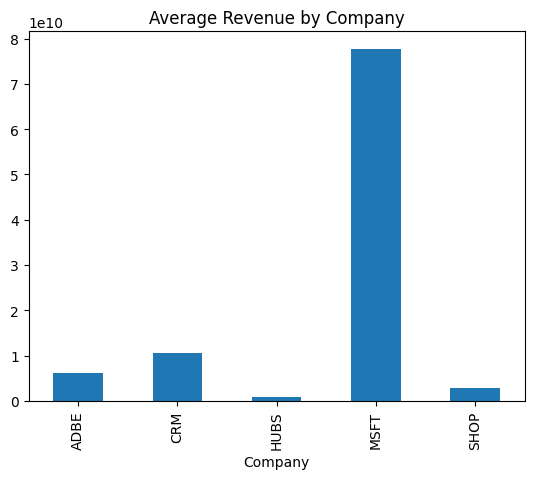

In [26]:
import matplotlib.pyplot as plt

df.groupby("Company")["Revenue"].mean().plot(kind="bar")
plt.title("Average Revenue by Company")
plt.show()

Microsoft has the highest average revenue among SaaS companies.
This indicates strong market dominance and diversified income streams.
Other companies show significantly lower revenue levels.

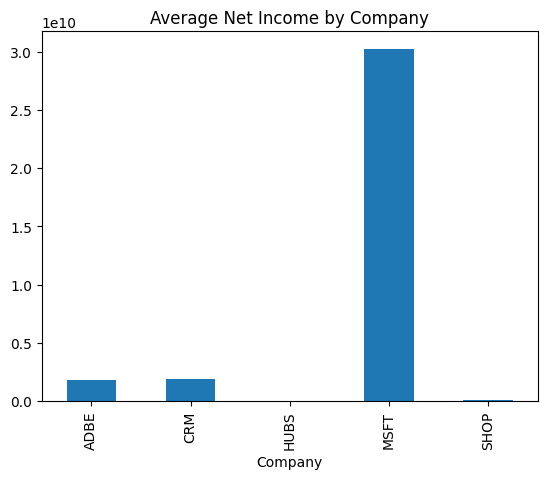

In [27]:
df.groupby("Company")["NetIncome"].mean().plot(kind="bar")
plt.title("Average Net Income by Company")
plt.show()

Net income varies significantly across companies.
Adobe and Microsoft show stable profitability, while others fluctuate more.
This suggests differences in operational efficiency.

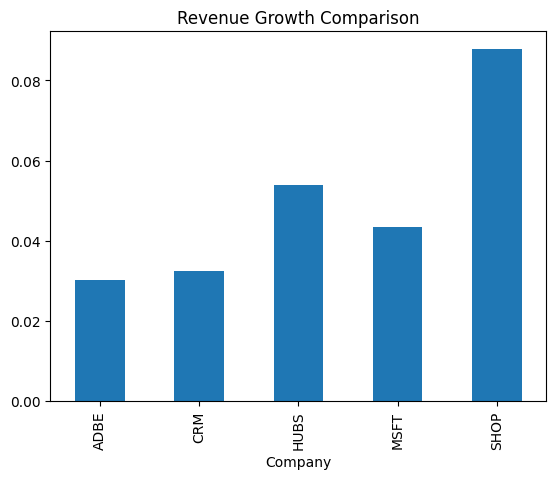

In [28]:
df.groupby("Company")["Revenue_Growth"].mean().plot(kind="bar")
plt.title("Revenue Growth Comparison")
plt.show()

Revenue growth is not consistent across SaaS companies.
Some companies show high volatility, indicating aggressive scaling strategies.
Others have more stable but slower growth.

In [9]:
company_info = pd.DataFrame({
    "Company": ["MSFT", "CRM", "SHOP", "ADBE"],
    "Country": ["USA", "USA", "Canada", "USA"],
    "Sector": ["Tech", "SaaS", "E-commerce", "Creative"]
})

In [10]:
company_info.head()

,Company,Country,Sector
0,MSFT,USA,Tech
1,CRM,USA,SaaS
2,SHOP,Canada,E-commerce
3,ADBE,USA,Creative


In [16]:
merged_df.head()

,Date,Company,Revenue,NetIncome,OperatingIncome,Revenue_Growth,Country,Sector
0,2025-03-31,MSFT,7.006600e+10,2.582400e+10,3.200000e+10,NaN,USA,Tech
1,2025-06-30,MSFT,7.644100e+10,2.723300e+10,3.432300e+10,0.090986,USA,Tech
2,2025-09-30,MSFT,7.767300e+10,2.774700e+10,3.796100e+10,0.016117,USA,Tech
3,2025-12-31,MSFT,8.127300e+10,3.845800e+10,3.827500e+10,0.046348,USA,Tech
4,2026-03-31,MSFT,8.288600e+10,3.177800e+10,3.839800e+10,0.019847,USA,Tech


In [17]:
merged_df.groupby("Sector")["Revenue"].mean()

,Revenue
Sector,
Creative,6.214200e+09
E-commerce,2.945200e+09
SaaS,1.053160e+10
Tech,7.766780e+10


In [19]:
merged_df.groupby("Company")["Revenue_Growth"].mean()

,Revenue_Growth
Company,
ADBE,0.030326
CRM,0.032351
MSFT,0.043324
SHOP,0.087804


In [21]:
merged_df

,Date,Company,Revenue,NetIncome,OperatingIncome,Revenue_Growth,Country,Sector
0,2025-03-31,MSFT,7.006600e+10,2.582400e+10,3.200000e+10,NaN,USA,Tech
1,2025-06-30,MSFT,7.644100e+10,2.723300e+10,3.432300e+10,0.090986,USA,Tech
2,2025-09-30,MSFT,7.767300e+10,2.774700e+10,3.796100e+10,0.016117,USA,Tech
3,2025-12-31,MSFT,8.127300e+10,3.845800e+10,3.827500e+10,0.046348,USA,Tech
4,2026-03-31,MSFT,8.288600e+10,3.177800e+10,3.839800e+10,0.019847,USA,Tech
5,2025-04-30,CRM,9.829000e+09,1.541000e+09,1.978000e+09,NaN,USA,SaaS
6,2025-07-31,CRM,1.023600e+10,1.887000e+09,2.336000e+09,0.041408,USA,SaaS
7,2025-10-31,CRM,1.025900e+10,2.086000e+09,2.448000e+09,0.002247,USA,SaaS
8,2026-01-31,CRM,1.120100e+10,1.943000e+09,2.155000e+09,0.091822,USA,SaaS
9,2026-04-30,CRM,1.113300e+10,2.107000e+09,2.427000e+09,-0.006071,USA,SaaS


In [22]:
merged_df.to_csv("data.csv", index=False)

In [23]:
!pip install streamlit plotly

In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

df = pd.read_csv("data.csv")

st.set_page_config(page_title="SaaS Financial Dashboard", layout="wide")

st.title("SaaS Financial Performance Dashboard")

company = st.sidebar.selectbox("Company", sorted(df["Company"].unique()))

filtered = df[df["Company"] == company]

col1, col2, col3 = st.columns(3)

col1.metric("Average Revenue", f"{filtered['Revenue'].mean():,.0f}")
col2.metric("Average Net Income", f"{filtered['NetIncome'].mean():,.0f}")
col3.metric(
    "Average Revenue Growth",
    f"{filtered['Revenue_Growth'].mean():.2%}"
)

fig = px.line(
    filtered,
    x="Date",
    y="Revenue",
    title=f"{company} Quarterly Revenue"
)

st.plotly_chart(fig, use_container_width=True)

Writing app.py


In [25]:
%%writefile requirements.txt
streamlit
pandas
plotly

Writing requirements.txt


In [26]:
merged_df["Growth_Momentum"] = (
    merged_df["Revenue_Growth"] * 0.6 +
    (merged_df["OperatingIncome"] / merged_df["Revenue"]) * 0.4
)

In [27]:
merged_df["Profit_Efficiency"] = merged_df["OperatingIncome"] / merged_df["Revenue"]

In [28]:
merged_df["Revenue_Stability"] = merged_df.groupby("Company")["Revenue"].transform(
    lambda x: 1 - x.pct_change().std()
)

In [29]:
merged_df["SaaS_Score"] = (
    merged_df["Growth_Momentum"] * 0.5 +
    merged_df["Profit_Efficiency"] * 0.3 +
    merged_df["Revenue_Stability"] * 0.2
)

In [30]:
import numpy as np

print("Avg SaaS Score:", merged_df["SaaS_Score"].mean())
print("Avg Growth Momentum:", merged_df["Growth_Momentum"].mean())
print("Avg Profit Efficiency:", merged_df["Profit_Efficiency"].mean())

Avg SaaS Score: 0.35333653454543734
Avg Growth Momentum: 0.1506773834417471
Avg Profit Efficiency: 0.29995553178672835


In [31]:
import ipywidgets as widgets
from IPython.display import display

In [32]:
company_dropdown = widgets.Dropdown(
    options=merged_df["Company"].unique(),
    description="Company:"
)

display(company_dropdown)

Dropdown(description='Company:', options=('MSFT', 'CRM', 'SHOP', 'ADBE'), value='MSFT')

In [33]:
def filter_data(company):
    return merged_df[merged_df["Company"] == company]

filtered_df = filter_data(company_dropdown.value)
filtered_df.head()

,Date,Company,Revenue,NetIncome,OperatingIncome,Revenue_Growth,Country,Sector,Growth_Momentum,Profit_Efficiency,Revenue_Stability,SaaS_Score
0,2025-03-31,MSFT,7.006600e+10,2.582400e+10,3.200000e+10,NaN,USA,Tech,NaN,0.456712,0.965493,NaN
1,2025-06-30,MSFT,7.644100e+10,2.723300e+10,3.432300e+10,0.090986,USA,Tech,0.234197,0.449013,0.965493,0.444901
2,2025-09-30,MSFT,7.767300e+10,2.774700e+10,3.796100e+10,0.016117,USA,Tech,0.205162,0.488728,0.965493,0.442298
3,2025-12-31,MSFT,8.127300e+10,3.845800e+10,3.827500e+10,0.046348,USA,Tech,0.216186,0.470944,0.965493,0.442475
4,2026-03-31,MSFT,8.288600e+10,3.177800e+10,3.839800e+10,0.019847,USA,Tech,0.197213,0.463263,0.965493,0.430684


In [34]:
def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        display(filter_data(change["new"]))

company_dropdown.observe(on_change)

In [35]:
import plotly.express as px

def plot_dashboard(company):
    df = merged_df[merged_df["Company"] == company]

    fig = px.line(
        df,
        x="Date",
        y="Revenue",
        title=f"{company} Revenue Trend"
    )
    fig.show()

plot_dashboard(company_dropdown.value)

In [36]:
df = merged_df[merged_df["Company"] == company_dropdown.value]

print("Revenue Avg:", df["Revenue"].mean())
print("Growth Momentum:", df["Growth_Momentum"].mean())
print("SaaS Score:", df["SaaS_Score"].mean())

Revenue Avg: 77667800000.0
Growth Momentum: 0.21318939888945468
SaaS Score: 0.44008939740495717


In [38]:
import ipywidgets as widgets
from IPython.display import display

company_dropdown = widgets.Dropdown(
    options=merged_df["Company"].unique(),
    description="Company:"
)

display(company_dropdown)

Dropdown(description='Company:', options=('MSFT', 'CRM', 'SHOP', 'ADBE'), value='MSFT')

In [39]:
import pandas as pd
import plotly.express as px

In [40]:
def plot_revenue(company):
    df = merged_df[merged_df["Company"] == company].copy()

    # Date sıralama
    df = df.sort_values("Date")

    # Moving Average (3 dönem)
    df["Revenue_MA"] = df["Revenue"].rolling(window=3).mean()

    fig = px.line(
        df,
        x="Date",
        y=["Revenue", "Revenue_MA"],
        title=f"{company} Revenue vs Moving Average"
    )

    fig.show()

In [41]:
def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        plot_revenue(change["new"])

company_dropdown.observe(on_change)

In [42]:
import pandas as pd
import yfinance as yf

companies = ["MSFT", "CRM", "SHOP", "ADBE"]

all_data = []

for c in companies:
    ticker = yf.Ticker(c)
    df = ticker.quarterly_financials.T
    df.columns = df.columns.str.strip()

    temp = pd.DataFrame(index=df.index)
    temp["Company"] = c
    temp["Revenue"] = df.get("Total Revenue")
    temp["NetIncome"] = df.get("Net Income")
    temp["OperatingIncome"] = df.get("Operating Income")

    all_data.append(temp)

final_df = pd.concat(all_data).reset_index().rename(columns={"index": "Date"})
final_df["Revenue_Growth"] = final_df.groupby("Company")["Revenue"].pct_change()

/tmp/ipykernel_1498/309347816.py:22: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [43]:
company_info = pd.DataFrame({
    "Company": ["MSFT", "CRM", "SHOP", "ADBE"],
    "Country": ["USA", "USA", "Canada", "USA"],
    "Sector": ["Tech", "SaaS", "E-commerce", "Creative"]
})

In [44]:
merged_df = final_df.merge(company_info, on="Company", how="left")

In [45]:
merged_df["Growth_Momentum"] = (
    merged_df["Revenue_Growth"] * 0.6 +
    (merged_df["OperatingIncome"] / merged_df["Revenue"]) * 0.4
)

merged_df["Profit_Efficiency"] = merged_df["OperatingIncome"] / merged_df["Revenue"]

merged_df["SaaS_Score"] = (
    merged_df["Growth_Momentum"] * 0.5 +
    merged_df["Profit_Efficiency"] * 0.5
)

In [46]:
import ipywidgets as widgets
from IPython.display import display

company_dropdown = widgets.Dropdown(
    options=merged_df["Company"].unique(),
    description="Company:"
)

display(company_dropdown)

Dropdown(description='Company:', options=('MSFT', 'CRM', 'SHOP', 'ADBE'), value='MSFT')

In [47]:
import plotly.express as px

def dashboard(company):
    df = merged_df[merged_df["Company"] == company].copy()
    df = df.sort_values("Date")

    # Moving Average
    df["Revenue_MA"] = df["Revenue"].rolling(window=3).mean()

    # KPI PRINT
    print("Revenue Avg:", df["Revenue"].mean())
    print("Growth Momentum:", df["Growth_Momentum"].mean())
    print("SaaS Score:", df["SaaS_Score"].mean())

    # PLOT
    fig = px.line(
        df,
        x="Date",
        y=["Revenue", "Revenue_MA"],
        title=f"{company} Revenue Trend (Raw vs Smoothed)"
    )
    fig.show()

In [48]:
def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        dashboard(change["new"])

company_dropdown.observe(on_change)

In [49]:
dashboard(merged_df["Company"].iloc[0])

Revenue Avg: 77667800000.0
Growth Momentum: 0.1620875247111908
SaaS Score: 0.31421841282484264


In [50]:
def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        dashboard(change["new"])

In [51]:
company_dropdown.observe(on_change)

In [53]:
display(company_dropdown)
dashboard(company_dropdown.value)

Dropdown(description='Company:', options=('MSFT', 'CRM', 'SHOP', 'ADBE'), value='MSFT')

Revenue Avg: 77667800000.0
Growth Momentum: 0.1620875247111908
SaaS Score: 0.31421841282484264


In [54]:
sector_df = merged_df.groupby("Sector")["Revenue"].mean().reset_index()

fig = px.bar(
    sector_df,
    x="Sector",
    y="Revenue",
    title="Revenue by Sector"
)
fig.show()